In [1]:
import pandas as pd
import os
from pathlib import Path
import numpy as np

In [2]:
Path.cwd()
data_path = Path.cwd().parent.parent
print(data_path) 

e:\anyfintech\research\in-progress\volatility-forecasting-based-on-DQN\volatility-forecasting


In [3]:
data = pd.read_csv(data_path/'data'/'processed'/'one_step_dqn_data_1D.csv')

In [4]:
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values(["stock", "Date"]).copy()


In [5]:
data["avg_rv_60"] = (
    data.groupby("stock")["rv"]
        .transform(
            lambda x: x.shift(1).rolling(
                window=60,
                min_periods=60,
            ).mean()
        )
)

In [6]:
# 根据所有有效的60日平均RV划分三等份
data["rv_regime"] = pd.qcut(
    data["avg_rv_60"],
    q=6,
    labels=[
        "Lowest",
        "Low",
        "Mid-low",
        "Mid-high",
        "High",
        "Highest",
    ],
)

In [7]:
prediction_cols = [
    "ols_prediction",
    "har_prediction",
    "lstm_prediction",
    "tcn_short_prediction",
    "tcn_medium_prediction",
    "tcn_long_prediction",
]

for pred_col in prediction_cols:
    model = pred_col.removesuffix("_prediction")
    # MSE：在 log-RV 尺度计算
    data[f"{model}_mse"] = (
        data["log_rv"] - data[pred_col]
    ) ** 2
    # QLIKE：等价形式，可直接用 log-RV 和预测 log-RV 计算
    log_ratio = data["log_rv"] - data[pred_col]
    data[f"{model}_qlike"] = (
        np.exp(log_ratio) - log_ratio - 1
    )

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# -------------------------
# 1. 整理数据
# -------------------------
model_order = [
    "ols",
    "har",
    "lstm",
    "tcn_short",
    "tcn_medium",
    "tcn_long",
]

model_labels = [
    "AR",
    "HAR",
    "LSTM",
    "TCN-short",
    "TCN-medium",
    "TCN-long",
]

regime_order = [
    "Lowest",
    "Low",
    "Mid-low",
    "Mid-high",
    "High",
    "Highest",
]

loss_cols = [f"{model}_qlike" for model in model_order]

raw_values = (
    data.groupby("rv_regime", observed=True)[loss_cols]
        .mean()
        .T
)

raw_values.index = model_labels
raw_values = raw_values.reindex(columns=regime_order)



In [53]:

# -------------------------
# 2. 每列内部标准化
# 颜色只反映同一 regime 下的相对表现
# -------------------------
column_min = raw_values.min(axis=0)
column_range = raw_values.max(axis=0) - column_min

In [54]:
normalized_values = (
    raw_values.subtract(column_min, axis=1)
              .divide(column_range.replace(0, np.nan), axis=1)
)

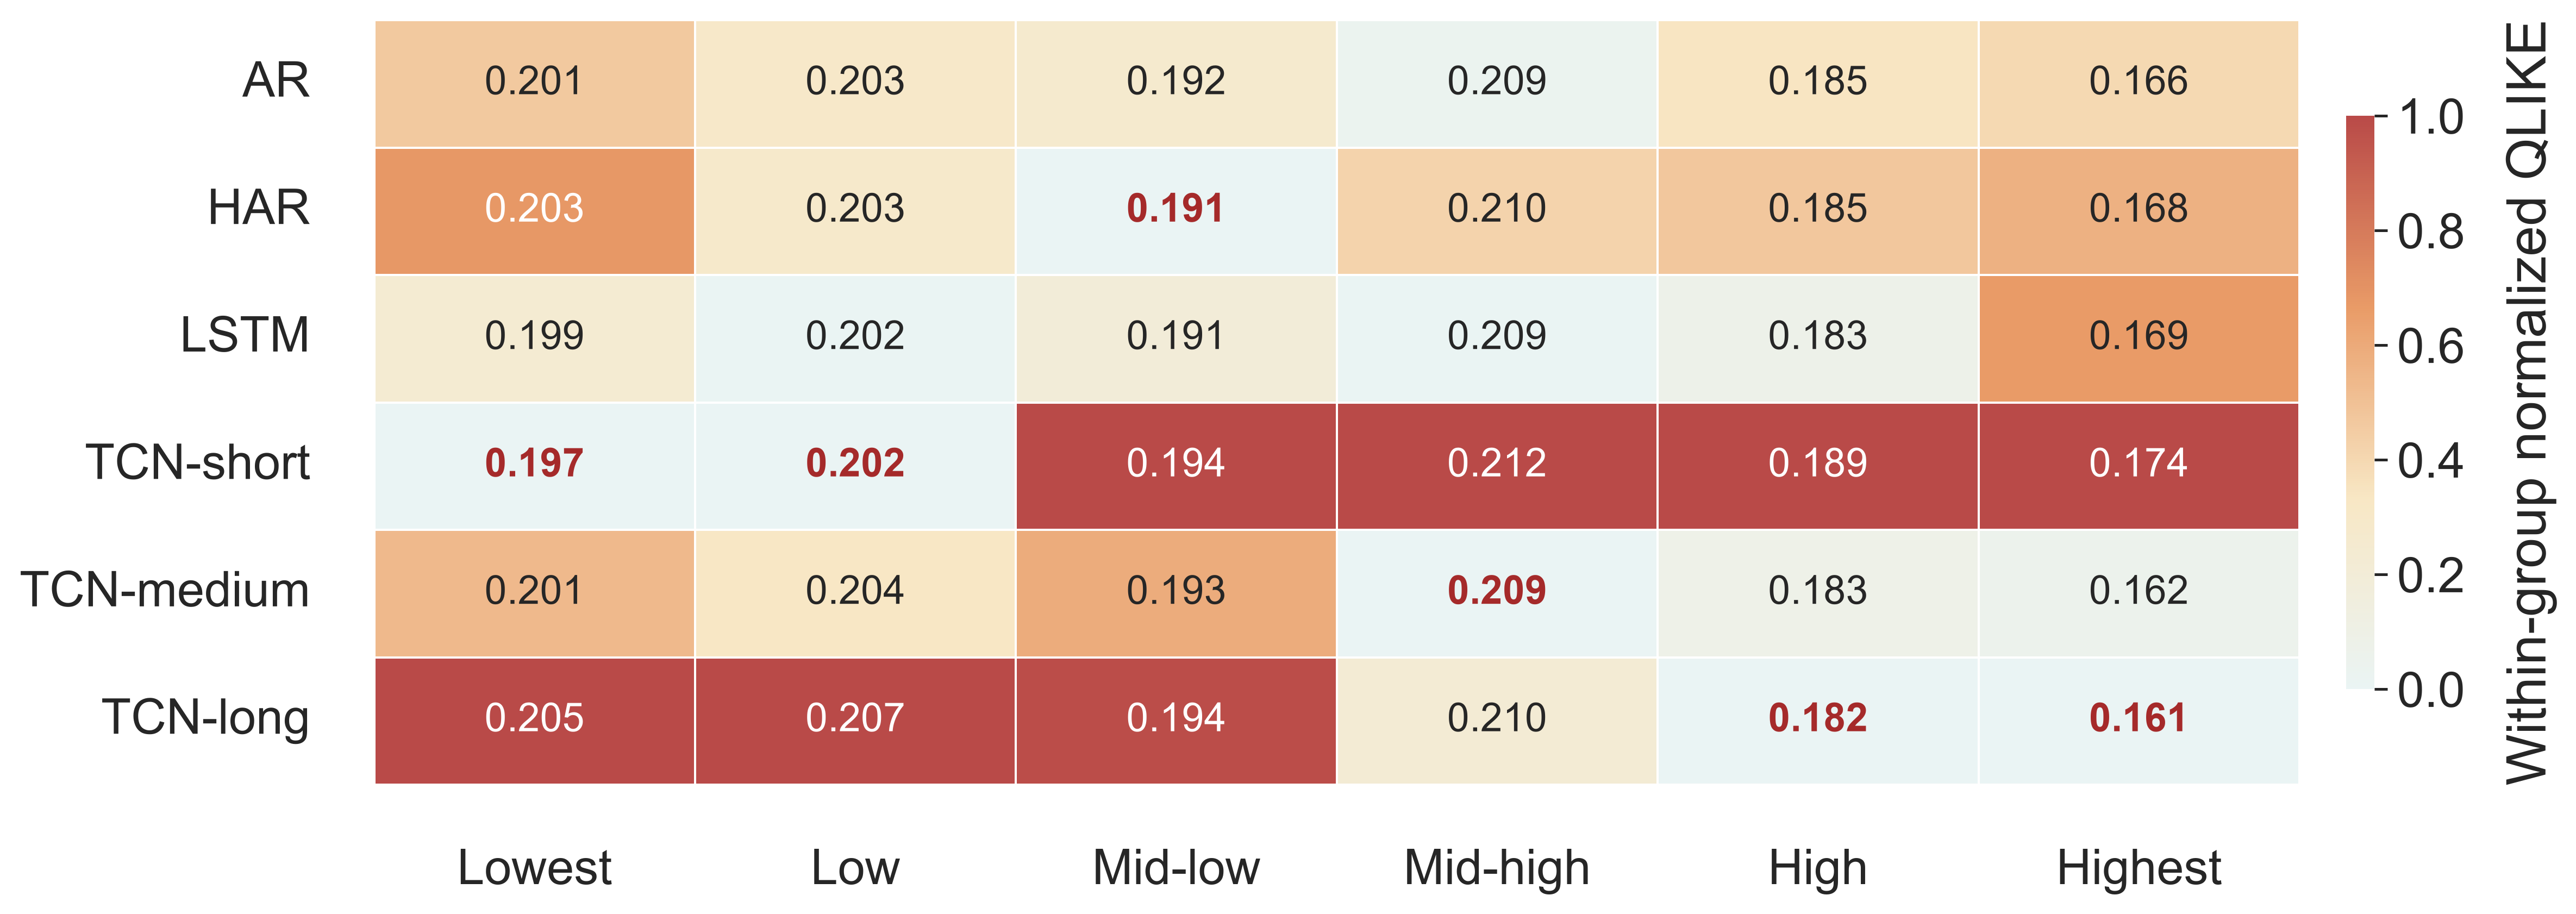

In [56]:
# 最优模型对应 0，最差模型对应 1
best_cells = raw_values.eq(raw_values.min(axis=0), axis=1)

# -------------------------
# 3. 更柔和的论文配色
# -------------------------
custom_cmap = LinearSegmentedColormap.from_list(
    "publication_heatmap",
    ["#EAF4F4", "#F8E7C4", "#E99B67", "#B94A48"],
)

sns.set_theme(
    style="white",
    context="paper",
    font_scale=1.15,
)

fig, ax = plt.subplots(figsize=(14, 4.8), dpi=360)

heatmap = sns.heatmap(
    normalized_values,
    ax=ax,
    cmap=custom_cmap,
    vmin=0,
    vmax=1,
    annot=raw_values,
    fmt=".3f",
    linewidths=0.8,
    linecolor="white",
    square=False,
    cbar_kws={
        "label": "Within-group normalized QLIKE",
        "shrink": 0.75,
        "pad": 0.02,
    },
    annot_kws={
        "fontsize": 14.5,
    },
)

# -------------------------
# 4. 突出每列最优模型
# -------------------------
for i in range(raw_values.shape[0]):
    for j in range(raw_values.shape[1]):
        text = ax.texts[i * raw_values.shape[1] + j]

        if best_cells.iloc[i, j]:
            text.set_weight("bold")
            text.set_color("brown")

colorbar = heatmap.collections[0].colorbar
colorbar.set_label("Within-group normalized QLIKE", fontsize=20,
                #    color = 'grey',
                   labelpad=15,)
colorbar.ax.tick_params(labelsize=18)

# 删除横轴、纵轴名称
ax.set_xlabel("")
ax.set_ylabel("")

ax.set_xticklabels(
    regime_order,
    # color = 'grey',
    fontsize = 18,
    rotation=0
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    fontsize = 18,
    # color = 'grey'
)

ax.tick_params(axis="both", length=20)

# 去掉外围边框
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
fig.savefig(
    data_path/'data'/'figs'/"QLIKE_Heatmap.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.show()